# `torchvision.transforms`로 데이터 증강 적용하기

### 문제 설명
이미지 데이터에 **torchvision.transforms**를 사용해 데이터 증강 기법을 적용합니다. 다음 변환을 통해 입력 데이터의 다양성을 높이는 것이 목표입니다:
- **Random Horizontal Flip**: 0.5 확률로 이미지를 좌우 반전합니다.
- **Random Crop**: 이미지를 지정한 크기로 무작위 자릅니다.
- **Normalization**: 지정한 평균과 표준편차로 이미지를 정규화합니다.

또한, 증강된 이미지 배치를 시각화해 변환이 올바르게 적용되었는지 확인합니다.

### 요구사항
1. **데이터 증강 적용**:
   - **torchvision.transforms**를 사용해 다음을 적용합니다:
     - **Random Horizontal Flip**: 0.5 확률로 이미지를 무작위로 좌우 반전합니다.
     - **Random Crop**: 이미지를 28x28 크기로 무작위 자릅니다.
     - **Normalization**: 지정된 평균과 표준편차 값으로 이미지를 정규화합니다.

2. **증강 검증**:
   - **matplotlib**를 사용해 증강된 이미지 배치를 시각화하여 변환이 올바르게 적용되었는지 확인합니다.

### 제약 사항
- 변환은 올바른 순서로 적용되어야 합니다.
- CIFAR-10 같은 일반적인 데이터셋에서 사용하는 값처럼 적절한 평균과 표준편차를 사용해 이미지를 정규화하세요.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as data
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load CIFAR-10 dataset with data augmentation
# TODO: Apply random horizontal flip, random crop, and normalization to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


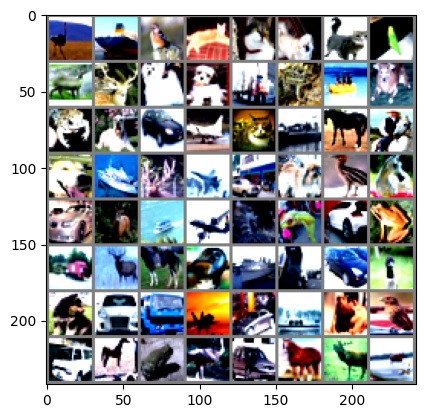

In [4]:
# Display a batch of augmented images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show images
imshow(torchvision.utils.make_grid(images))
